# 1. Introduction

The generated kidney-transplant dataset has already been created and validated. It contains 10,000 synthetic recipients and 60,000 longitudinal assessments. This notebook begins the predictive-modelling stage by training the original baseline against which later machine-unlearning methods will be compared. The baseline is a reference model, not an unlearning method.

Each row is one post-transplant assessment. The model estimates `acute_rejection_within_30_days`: class `0` means continue standard monitoring, while class `1` means priority transplant-team review and further investigation. It estimates research risk; it neither diagnoses rejection nor makes an autonomous clinical decision.

All data are generated and the model is for machine-unlearning research. It is not clinically validated. Direct identifiers are excluded from model inputs. Notebook 01 neither creates forget sets nor performs unlearning.

# 2. Setup and reproducibility

This section fixes the project paths, seed and deterministic CPU settings used by the baseline. Later unlearning experiments reuse the same setup.

In [1]:
# Import only the libraries required by the established notebook workflow.
import copy
import json
import platform
import random
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
from IPython.display import Markdown, display

In [2]:
# Import only the libraries required by the established notebook workflow.
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedGroupKFold


In [3]:
# Import only the libraries required by the established notebook workflow.
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

Paths are resolved from the clean `final_submission` workspace, with no machine-specific absolute path. Only established baseline output directories are created.

In [4]:
def locate_submission_root() -> Path:
    # Support execution from the repository root or notebook directory.
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents, cwd / "final_submission"]:
        direct = candidate / "data/final/kidney_transplant_assessments.csv"
        nested = candidate / "final_submission/data/final/kidney_transplant_assessments.csv"
        if direct.is_file():
            return candidate
        if nested.is_file():
            return candidate / "final_submission"
    raise FileNotFoundError("Could not locate final_submission/data/final")


SUBMISSION_ROOT = locate_submission_root()
DATA_DIR = SUBMISSION_ROOT / "data/final"
PROCESSED_DIR = SUBMISSION_ROOT / "processed_data"
MODEL_DIR = SUBMISSION_ROOT / "models/baseline"
RESULT_DIR = SUBMISSION_ROOT / "results/baseline"


In [5]:
# Save reproducibility artefacts only after the corresponding checks have passed.
FIGURE_DIR = RESULT_DIR / "figures"
for directory in (PROCESSED_DIR, MODEL_DIR, RESULT_DIR, FIGURE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

ASSESSMENT_PATH = DATA_DIR / "kidney_transplant_assessments.csv"
FEATURE_LIST_PATH = DATA_DIR / "classifier_feature_list.json"
DICTIONARY_PATH = DATA_DIR / "data_dictionary.csv"
(RESULT_DIR / "run_summary.json").write_text(
    json.dumps({"status": "running", "task": "baseline kidney-transplant classifier"}, indent=2) + "\n",
    encoding="utf-8",
)

77

Seed 42 is fixed for Python, NumPy and PyTorch, with deterministic CPU execution where appropriate. The same controls are reset immediately before model construction so inspection and splitting cannot change the trained result through global RNG-state consumption.

In [6]:
# Freeze all random generators so later reruns reproduce the baseline.
SEED = 42
DEVICE = torch.device("cpu")


def reset_training_seed() -> None:
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)


reset_training_seed()
torch.use_deterministic_algorithms(True)
torch.set_num_threads(1)

This compact summary records the principal reproducibility controls and local paths.

In [7]:
# Keep this stage separate so its inputs and checks remain easy to audit.
display(pd.Series({
    "seed": SEED,
    "device": str(DEVICE),
    "assessment_data": ASSESSMENT_PATH.relative_to(SUBMISSION_ROOT).as_posix(),
    "feature_contract": FEATURE_LIST_PATH.relative_to(SUBMISSION_ROOT).as_posix(),
    "processed_data": PROCESSED_DIR.relative_to(SUBMISSION_ROOT).as_posix(),
    "model_output": MODEL_DIR.relative_to(SUBMISSION_ROOT).as_posix(),
    "results_output": RESULT_DIR.relative_to(SUBMISSION_ROOT).as_posix(),
}).to_frame("value"))

,value
seed,42
device,cpu
assessment_data,data/final/kidney_transplant_assessments.csv
feature_contract,data/final/classifier_feature_list.json
processed_data,processed_data
model_output,models/baseline
results_output,results/baseline


# 3. Load and inspect the dataset

The authoritative assessment CSV is loaded without alteration. Structural assertions verify its agreed dimensions and longitudinal unit of analysis; hash verification is intentionally outside the teaching narrative.

In [8]:
# Load the immutable final assessment table used by every modelling stage.
assessments = pd.read_csv(ASSESSMENT_PATH)
assert assessments.shape == (60_000, 31)
assert assessments["recipient_id"].nunique() == 10_000
assert assessments.groupby("recipient_id").size().eq(6).all()

display(pd.Series({
    "assessment rows": len(assessments),
    "columns": assessments.shape[1],
    "recipients": assessments["recipient_id"].nunique(),
    "assessments per recipient": 6,
}).to_frame("confirmed value"))

,confirmed value
assessment rows,60000
columns,31
recipients,10000
assessments per recipient,6


Focused previews and summaries make the table inspectable without printing the complete dataset.

In [9]:
# Keep this stage separate so its inputs and checks remain easy to audit.
display(assessments.head(3))
display(assessments.tail(3))
print(f"Shape: {assessments.shape[0]:,} rows × {assessments.shape[1]} columns")
print("Columns:", assessments.columns.tolist())

,assessment_id,recipient_id,donor_id,hospital_id,assessment_date,training_consent_status,training_consent_version,retention_expiry_date,recipient_sex,recipient_ethnicity,...,cold_ischaemia_hours,days_since_transplant,creatinine_mg_dl,creatinine_change_pct,urine_output_ml_24h,tacrolimus_level_ng_ml,medication_adherence_pct,infection_indicator,previous_rejection,acute_rejection_within_30_days
0,V32P-A000001,V32P-R000001,V32P-DD000416,V32P-H07,2023-12-26,Active,RECIPIENT_V1,2025-12-25,Female,Black,...,4.62,7,1.24,-3.651904,2450.6,9.88,86.3,0,0,1
1,V32P-A000002,V32P-R000001,V32P-DD000416,V32P-H07,2024-01-02,Active,RECIPIENT_V2,2026-01-01,Female,Black,...,4.62,14,1.18,-4.838710,2380.0,9.50,88.1,0,0,1
2,V32P-A000003,V32P-R000001,V32P-DD000416,V32P-H07,2024-01-18,Active,RECIPIENT_V4,2026-01-17,Female,Black,...,4.62,30,1.35,14.406780,2150.0,10.20,82.5,1,0,1


,assessment_id,recipient_id,donor_id,hospital_id,assessment_date,training_consent_status,training_consent_version,retention_expiry_date,recipient_sex,recipient_ethnicity,...,cold_ischaemia_hours,days_since_transplant,creatinine_mg_dl,creatinine_change_pct,urine_output_ml_24h,tacrolimus_level_ng_ml,medication_adherence_pct,infection_indicator,previous_rejection,acute_rejection_within_30_days
59997,V32P-A059998,V32P-R010000,V32P-DL002806,V32P-H07,2024-06-05,Active,RECIPIENT_V4,2026-06-05,Male,Other,...,2.92,60,1.05,-8.695652,1980.0,10.2,94.2,0,0,0
59998,V32P-A059999,V32P-R010000,V32P-DL002806,V32P-H07,2024-07-05,Active,RECIPIENT_V4,2026-07-05,Male,Other,...,2.92,90,0.98,-6.666667,1920.0,9.5,93.5,0,0,0
59999,V32P-A060000,V32P-R010000,V32P-DL002806,V32P-H07,2024-10-03,Active,RECIPIENT_V4,2026-10-03,Male,Other,...,2.92,180,0.92,-6.122449,1850.0,8.8,92.1,0,0,0


Shape: 60,000 rows × 31 columns
Columns: ['assessment_id', 'recipient_id', 'donor_id', 'hospital_id', 'assessment_date', 'training_consent_status', 'training_consent_version', 'retention_expiry_date', 'recipient_sex', 'recipient_ethnicity', 'recipient_region', 'distance_to_transplant_centre_km', 'recipient_age', 'donor_age', 'donor_type', 'kidney_failure_cause', 'previous_transplant', 'dialysis_months', 'abo_compatibility_category', 'hla_mismatch_count', 'antibody_risk_score', 'cold_ischaemia_hours', 'days_since_transplant', 'creatinine_mg_dl', 'creatinine_change_pct', 'urine_output_ml_24h', 'tacrolimus_level_ng_ml', 'medication_adherence_pct', 'infection_indicator', 'previous_rejection', 'acute_rejection_within_30_days']


In [10]:
assessments.info(show_counts=True, memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 31 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   assessment_id                     60000 non-null  str    
 1   recipient_id                      60000 non-null  str    
 2   donor_id                          60000 non-null  str    
 3   hospital_id                       60000 non-null  str    
 4   assessment_date                   60000 non-null  str    
 5   training_consent_status           60000 non-null  str    
 6   training_consent_version          60000 non-null  str    
 7   retention_expiry_date             60000 non-null  str    
 8   recipient_sex                     60000 non-null  str    
 9   recipient_ethnicity               60000 non-null  str    
 10  recipient_region                  60000 non-null  str    
 11  distance_to_transplant_centre_km  60000 non-null  float64
 12  recipient_age  

In [11]:
# Inspect clinical ranges without using them to choose model inputs.
inspection_numeric = [
    "recipient_age", "donor_age", "dialysis_months", "hla_mismatch_count",
    "antibody_risk_score", "cold_ischaemia_hours", "days_since_transplant",
    "creatinine_mg_dl", "creatinine_change_pct", "urine_output_ml_24h",
    "tacrolimus_level_ng_ml", "medication_adherence_pct",
]
display(assessments[inspection_numeric].describe().T.round(3))

,count,mean,std,min,25%,50%,75%,max
recipient_age,60000.0,50.006,16.342,22.000,36.000,50.000,64.000,78.000
donor_age,60000.0,47.580,13.229,25.000,36.000,48.000,59.000,70.000
dialysis_months,60000.0,37.424,20.219,3.000,20.000,38.000,55.000,72.000
hla_mismatch_count,60000.0,3.000,2.010,0.000,1.000,3.000,5.000,6.000
antibody_risk_score,60000.0,0.496,0.252,0.060,0.277,0.499,0.716,0.930
cold_ischaemia_hours,60000.0,11.432,5.409,2.200,6.670,11.300,16.110,20.900
days_since_transplant,60000.0,63.500,59.234,7.000,14.000,45.000,90.000,180.000
creatinine_mg_dl,60000.0,1.173,0.277,0.650,0.950,1.150,1.350,2.720
creatinine_change_pct,60000.0,-0.770,8.367,-36.552,-5.726,-2.778,4.516,70.588
urine_output_ml_24h,60000.0,2115.335,302.641,1200.000,1900.000,2100.000,2310.000,3150.000


In [12]:
# Check category coverage without changing the frozen feature contract.
inspection_categorical = [
    "donor_type", "kidney_failure_cause", "abo_compatibility_category",
    "recipient_sex", "recipient_ethnicity", "recipient_region",
]
categorical_summary = pd.DataFrame([
    {
        "field": field,
        "unique values": assessments[field].nunique(),
        "most common": assessments[field].mode().iloc[0],
        "most-common count": assessments[field].value_counts().iloc[0],
    }
    for field in inspection_categorical
])
display(categorical_summary)

,field,unique values,most common,most-common count
0,donor_type,2,Deceased,36000
1,kidney_failure_cause,5,Diabetic kidney disease,12000
2,abo_compatibility_category,2,Standard compatible,33000
3,recipient_sex,2,Female,30000
4,recipient_ethnicity,5,Asian,12000
5,recipient_region,5,London,12000


In [13]:
# Confirm each recipient contributes one complete longitudinal history.
longitudinal_summary = assessments.groupby("recipient_id").agg(
    assessment_count=("assessment_id", "size"),
    first_day=("days_since_transplant", "min"),
    last_day=("days_since_transplant", "max"),
)
display(longitudinal_summary.describe().round(2))
print("Observed assessment days:", sorted(assessments["days_since_transplant"].unique()))

,assessment_count,first_day,last_day
count,10000.0,10000.0,10000.0
mean,6.0,7.0,180.0
std,0.0,0.0,0.0
min,6.0,7.0,180.0
25%,6.0,7.0,180.0
50%,6.0,7.0,180.0
75%,6.0,7.0,180.0
max,6.0,7.0,180.0


Observed assessment days: [np.int64(7), np.int64(14), np.int64(30), np.int64(60), np.int64(90), np.int64(180)]


These checks validate readiness for modelling. They do not clean or rewrite the already validated data.

In [14]:
# Confirm the longitudinal schedule before constructing model inputs.
expected_days = [7, 14, 30, 60, 90, 180]
observed_days = sorted(assessments["days_since_transplant"].unique().tolist())
assessment_counts = assessments.groupby("recipient_id").size()
observed_quality = {
    "Missing values": int(assessments.isna().sum().sum()),
    "Duplicate rows": int(assessments.duplicated().sum()),
    "Duplicate assessment IDs": int(assessments["assessment_id"].duplicated().sum()),
    "Duplicate recipient-day combinations": int(
        assessments.duplicated(["recipient_id", "days_since_transplant"]).sum()
    ),
    "Recipients with exactly six assessments": int(assessment_counts.eq(6).sum()),
    "Unexpected assessment days": len(set(observed_days) - set(expected_days)),
}


In [15]:
# Fail early if this stage no longer matches the frozen experiment contract.
expected_quality = {
    "Missing values": 0, "Duplicate rows": 0, "Duplicate assessment IDs": 0,
    "Duplicate recipient-day combinations": 0,
    "Recipients with exactly six assessments": 10_000,
    "Unexpected assessment days": 0,
}
quality_table = pd.DataFrame({"observed": observed_quality, "expected": expected_quality})
quality_table["status"] = np.where(quality_table["observed"].eq(quality_table["expected"]), "PASS", "FAIL")
assert quality_table["status"].eq("PASS").all()
assert observed_days == expected_days
assert set(assessments["acute_rejection_within_30_days"].unique()) == {0, 1}
display(quality_table)
print("No cleaning is required; the validated data are ready for modelling.")

,observed,expected,status
Missing values,0,0,PASS
Duplicate rows,0,0,PASS
Duplicate assessment IDs,0,0,PASS
Duplicate recipient-day combinations,0,0,PASS
Recipients with exactly six assessments,10000,10000,PASS
Unexpected assessment days,0,0,PASS


No cleaning is required; the validated data are ready for modelling.


Assessment-level counts and percentages are recalculated from the loaded target. The chart shows the class imbalance.

,count,percentage
0: standard monitoring,55506,92.51
1: priority review,4494,7.49


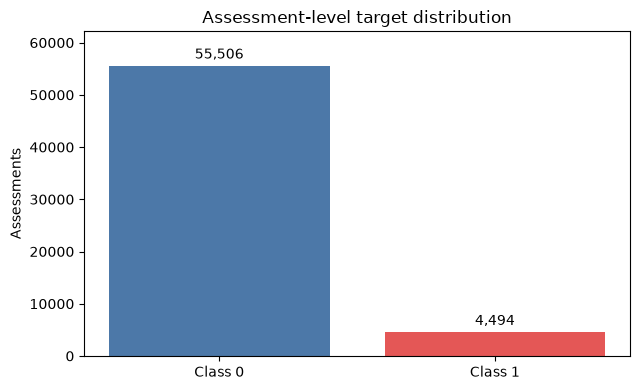

In [16]:
# Recalculate prevalence rather than relying on a saved summary.
target_column = "acute_rejection_within_30_days"
target_counts = assessments[target_column].value_counts().sort_index()
target_percentages = assessments[target_column].value_counts(normalize=True).sort_index() * 100
target_distribution = pd.DataFrame({"count": target_counts, "percentage": target_percentages})
target_distribution.index = ["0: standard monitoring", "1: priority review"]
assert target_counts.to_dict() == {0: 55_506, 1: 4_494}
display(target_distribution.round({"percentage": 3}))

fig, ax = plt.subplots(figsize=(6.5, 4))
bars = ax.bar(["Class 0", "Class 1"], target_counts.values, color=["#4c78a8", "#e45756"])
ax.bar_label(bars, labels=[f"{value:,}" for value in target_counts.values], padding=3)
ax.set(title="Assessment-level target distribution", ylabel="Assessments")
ax.set_ylim(0, target_counts.max() * 1.12)
fig.tight_layout()
plt.show()

The following summary brings the dataset checks and target distribution together.

In [17]:
# Keep this stage separate so its inputs and checks remain easy to audit.
recipient_positive = assessments.groupby("recipient_id")[target_column].max()
display(Markdown(
    f"The table contains **{len(assessments):,} assessments** from "
    f"**{assessments['recipient_id'].nunique():,} recipients**, with exactly six assessments at days "
    f"{expected_days}. All quality checks passed. At assessment level, **{int(target_counts[1]):,} of "
    f"{len(assessments):,} rows ({target_counts[1] / len(assessments):.2%})** are positive. At recipient "
    f"level, **{int(recipient_positive.sum()):,} of {len(recipient_positive):,} recipients "
    f"({recipient_positive.mean():.2%})** have at least one positive assessment. These prevalence values use "
    f"different denominators; the model is trained at assessment level."
))

The table contains **60,000 assessments** from **10,000 recipients**, with exactly six assessments at days [7, 14, 30, 60, 90, 180]. All quality checks passed. At assessment level, **4,494 of 60,000 rows (7.49%)** are positive. At recipient level, **2,473 of 10,000 recipients (24.73%)** have at least one positive assessment. These prevalence values use different denominators; the model is trained at assessment level.

# 4. Feature selection

The feature list and target are loaded from the authoritative JSON contract. The data dictionary confirms classifier roles and exclusions.

In [18]:
# Use the frozen feature contract shared with later unlearning notebooks.
feature_contract = json.loads(FEATURE_LIST_PATH.read_text(encoding="utf-8"))
data_dictionary = pd.read_csv(DICTIONARY_PATH)
classifier_features = feature_contract["classifier_features"]
target_column = feature_contract["target"]
dictionary_classifier_fields = data_dictionary.loc[
    (data_dictionary["table"] == "assessment")
    & data_dictionary["supplied_to_classifier"].astype(str).str.lower().eq("true"),
    "field_name",
].tolist()
assert classifier_features == dictionary_classifier_fields
assert target_column not in classifier_features

The ten static inputs are recipient age, donor age and type, kidney-failure cause, previous transplant, dialysis duration, ABO compatibility category, HLA mismatch count, antibody risk score and cold-ischaemia time. They provide generated context without implying causal effects.

The eight longitudinal inputs are assessment day, creatinine level and change, 24-hour urine output, tacrolimus level, medication adherence, infection indicator and previous rejection. They describe generated measurements or history available at that assessment; future events are not inputs.

In [19]:
# Separate static and longitudinal inputs for audit reporting.
static_features = classifier_features[:10]
longitudinal_features = classifier_features[10:]
assert static_features == [
    "recipient_age", "donor_age", "donor_type", "kidney_failure_cause",
    "previous_transplant", "dialysis_months", "abo_compatibility_category",
    "hla_mismatch_count", "antibody_risk_score", "cold_ischaemia_hours",
]
assert longitudinal_features == [
    "days_since_transplant", "creatinine_mg_dl", "creatinine_change_pct",
    "urine_output_ml_24h", "tacrolimus_level_ng_ml", "medication_adherence_pct",
    "infection_indicator", "previous_rejection",
]
display(pd.DataFrame({"static feature": static_features}))
display(pd.DataFrame({"time-varying feature": longitudinal_features}))

,static feature
0,recipient_age
1,donor_age
2,donor_type
3,kidney_failure_cause
4,previous_transplant
5,dialysis_months
6,abo_compatibility_category
7,hla_mismatch_count
8,antibody_risk_score
9,cold_ischaemia_hours


,time-varying feature
0,days_since_transplant
1,creatinine_mg_dl
2,creatinine_change_pct
3,urine_output_ml_24h
4,tacrolimus_level_ng_ml
5,medication_adherence_pct
6,infection_indicator
7,previous_rejection


The categorical inputs are `donor_type`, `kidney_failure_cause` and `abo_compatibility_category`; all other approved inputs are numerical or binary.

In [20]:
# Keep categorical and numerical columns in one fixed, auditable order.
categorical_features = ["donor_type", "kidney_failure_cause", "abo_compatibility_category"]
numeric_features = [feature for feature in classifier_features if feature not in categorical_features]
assert (len(classifier_features), len(numeric_features), len(categorical_features)) == (18, 15, 3)
display(pd.DataFrame({
    "group": ["numerical or binary", "categorical", "all raw inputs"],
    "count": [len(numeric_features), len(categorical_features), len(classifier_features)],
    "features": [", ".join(numeric_features), ", ".join(categorical_features), ", ".join(classifier_features)],
}))

,group,count,features
0,numerical or binary,15,"recipient_age, donor_age, previous_transplant,..."
1,categorical,3,"donor_type, kidney_failure_cause, abo_compatib..."
2,all raw inputs,18,"recipient_age, donor_age, donor_type, kidney_f..."


The target, identifiers, dates, consent/audit attributes, identity data and generation controls must not enter the classifier. `recipient_id`, `donor_id`, `hospital_id` and `assessment_id` remain only for grouping and audit.

In [21]:
# Reject identifiers, audit fields and the target before any fitting occurs.
excluded_roles = {"identifier", "audit field", "target"}
excluded_fields = set(
    data_dictionary.loc[data_dictionary["role"].isin(excluded_roles), "field_name"]
)
assert excluded_fields.isdisjoint(classifier_features)

prohibited_fragments = (
    "_id", "date", "consent", "retention", "anchor", "seed", "event_day",
    "generation", "request", "response", "person_", "full_name", "email",
    "postcode", "hospital_number",
)
assert not [
    feature for feature in classifier_features
    if any(fragment in feature.lower() for fragment in prohibited_fragments)
]


In [22]:
# Keep this stage separate so its inputs and checks remain easy to audit.


leakage_checks = pd.DataFrame([
    {"check": "Target excluded", "pass": target_column not in classifier_features},
    {"check": "Identifier/audit fields excluded", "pass": excluded_fields.isdisjoint(classifier_features)},
    {"check": "Generation controls excluded", "pass": True},
])
leakage_checks["status"] = leakage_checks.pop("pass").map({True: "PASS", False: "FAIL"})
display(leakage_checks)

,check,status
0,Target excluded,PASS
1,Identifier/audit fields excluded,PASS
2,Generation controls excluded,PASS


The feature summary below confirms the approved inputs and leakage checks.

In [23]:
# Keep this stage separate so its inputs and checks remain easy to audit.
display(Markdown(
    f"The authoritative contract supplies **{len(classifier_features)} raw inputs**: "
    f"{len(static_features)} static and {len(longitudinal_features)} longitudinal, comprising "
    f"{len(numeric_features)} numerical/binary and {len(categorical_features)} categorical features. "
    f"All leakage checks passed; identifiers remain outside the model matrix."
))

The authoritative contract supplies **18 raw inputs**: 10 static and 8 longitudinal, comprising 15 numerical/binary and 3 categorical features. All leakage checks passed; identifiers remain outside the model matrix.

# 5. Train, validation and test split

Training fits preprocessing and model parameters. Validation controls early stopping and threshold selection. Test is used once for final evaluation.

Row-wise splitting would leak assessments from the same recipient across partitions. The established seed-42 `StratifiedGroupKFold` creates 20 shuffled donor groups: folds 0–13 train, 14–16 validation and 17–19 test. Grouping by donor is deliberately stricter than grouping by recipient: it keeps all six assessments for each recipient together and also keeps recipients linked to the same donor in one split.

In [24]:
# Summarise at recipient level before assigning longitudinal records.
recipient_summary = (
    assessments.groupby("recipient_id", as_index=False)
    .agg(
        donor_id=("donor_id", "first"),
        recipient_target_any=(target_column, "max"),
        assessment_count=("assessment_id", "count"),
    )
    .sort_values("recipient_id")
    .reset_index(drop=True)
)
assert recipient_summary["assessment_count"].eq(6).all()

In [25]:
# Group by donor so related recipients cannot cross splits.
splitter = StratifiedGroupKFold(n_splits=20, shuffle=True, random_state=SEED)
fold_ids = np.empty(len(recipient_summary), dtype=np.int64)
dummy_x = np.zeros((len(recipient_summary), 1), dtype=np.float32)
for fold_id, (_, fold_indices) in enumerate(
    splitter.split(
        dummy_x,
        recipient_summary["recipient_target_any"],
        groups=recipient_summary["donor_id"],
    )
):
    fold_ids[fold_indices] = fold_id

recipient_summary["fold_id"] = fold_ids


In [26]:
# Keep this stage separate so its inputs and checks remain easy to audit.
recipient_summary["split"] = np.select(
    [recipient_summary["fold_id"] < 14, recipient_summary["fold_id"] < 17],
    ["train", "validation"],
    default="test",
)

In [27]:
# Convert the fixed fold numbers into permanent train, validation and test labels.
split_assignments = recipient_summary[
    ["recipient_id", "donor_id", "recipient_target_any", "assessment_count", "fold_id", "split"]
].copy()
split_summary = split_assignments.groupby("split").agg(
    recipients=("recipient_id", "count"),
    donors=("donor_id", "nunique"),
    positive_recipients=("recipient_target_any", "sum"),
    recipient_positive_prevalence=("recipient_target_any", "mean"),
)
display(split_summary)

,recipients,donors,positive_recipients,recipient_positive_prevalence
split,,,,
test,1498,1200,370,0.246996
train,7004,5601,1733,0.247430
validation,1498,1199,370,0.246996


Assessment-, recipient- and donor-level summaries use their relevant denominators. Pairwise intersections must be zero.

In [28]:
# Apply each recipient's permanent split to all six assessments.
split_by_recipient = split_assignments.set_index("recipient_id")["split"]
assessment_splits = assessments["recipient_id"].map(split_by_recipient)
assert assessment_splits.notna().all()

split_frames = {
    split: assessments.loc[assessment_splits.eq(split)].copy()
    for split in ("train", "validation", "test")
}

In [29]:
# Summarise class balance after applying the permanent split.
split_summary_rows = []
for split, frame in split_frames.items():
    recipient_targets = frame.groupby("recipient_id")[target_column].max()
    split_summary_rows.append({
        "split": split,
        "assessment_rows": len(frame),
        "recipients": frame["recipient_id"].nunique(),
        "donors": frame["donor_id"].nunique(),
        "positive_assessments": int(frame[target_column].sum()),
        "assessment_prevalence": frame[target_column].mean(),
        "positive_recipients": int(recipient_targets.sum()),
        "recipient_positive_prevalence": recipient_targets.mean(),
    })
split_summary = pd.DataFrame(split_summary_rows).set_index("split")
assert split_summary["assessment_rows"].to_dict() == {"train": 42_024, "validation": 8_988, "test": 8_988}


In [30]:
assert split_summary["recipients"].to_dict() == {"train": 7_004, "validation": 1_498, "test": 1_498}
display(split_summary)

,assessment_rows,recipients,donors,positive_assessments,assessment_prevalence,positive_recipients,recipient_positive_prevalence
split,,,,,,,
train,42024,7004,5601,3160,0.075195,1733,0.247430
validation,8988,1498,1199,669,0.074433,370,0.246996
test,8988,1498,1200,665,0.073988,370,0.246996


In [31]:
# Check both recipient and donor separation because either overlap would leak information.
recipient_sets = {name: set(frame["recipient_id"]) for name, frame in split_frames.items()}
donor_sets = {name: set(frame["donor_id"]) for name, frame in split_frames.items()}
assessment_sets = {name: set(frame["assessment_id"]) for name, frame in split_frames.items()}


def pairwise_overlap_counts(sets_by_split: dict[str, set]) -> dict[str, int]:
    names = list(sets_by_split)
    return {
        f"{names[i]}__{names[j]}": len(sets_by_split[names[i]] & sets_by_split[names[j]])
        for i in range(len(names))
        for j in range(i + 1, len(names))
    }

In [32]:
# Require zero overlap across recipients, donors and assessments.
recipient_overlap = pairwise_overlap_counts(recipient_sets)
donor_overlap = pairwise_overlap_counts(donor_sets)
assessment_overlap = pairwise_overlap_counts(assessment_sets)
assert not any(recipient_overlap.values())
assert not any(donor_overlap.values())
assert not any(assessment_overlap.values())
assert sum(len(frame) for frame in split_frames.values()) == len(assessments)

display(pd.DataFrame({
    'recipient overlap': recipient_overlap,
    'donor overlap': donor_overlap,
    'assessment-ID overlap': assessment_overlap,
}))

,recipient overlap,donor overlap,assessment-ID overlap
train__validation,0,0,0
train__test,0,0,0
validation__test,0,0,0


Regenerated assignments are compared with the preserved first-run membership and saved split tables. These permanent files are checked in place rather than replaced, and no alternative split is created.

In [33]:
# Reuse the established filenames required by later notebooks.
split_assignment_path = PROCESSED_DIR / "split_assignments.csv"
assert split_assignment_path.is_file(), "Preserved first-run split assignments are missing."
preserved_split_assignments = pd.read_csv(split_assignment_path)
comparison_columns = ["recipient_id", "donor_id", "recipient_target_any", "assessment_count", "fold_id", "split"]
pd.testing.assert_frame_equal(
    preserved_split_assignments[comparison_columns].sort_values("recipient_id").reset_index(drop=True),
    split_assignments[comparison_columns].sort_values("recipient_id").reset_index(drop=True),
    check_dtype=False,
)
preserved_split_membership_identical = True


In [34]:

# The permanent split and saved split frames are immutable inputs for this repair.
for split_name, filename in {
    "train": "training_assessments.csv",
    "validation": "validation_assessments.csv",
    "test": "test_assessments.csv",
}.items():
    saved_frame = pd.read_csv(PROCESSED_DIR / filename)
    pd.testing.assert_frame_equal(
        saved_frame.reset_index(drop=True),
        split_frames[split_name].reset_index(drop=True),
        check_dtype=False,
    )


In [35]:
# Confirm regenerated membership matches the preserved first execution exactly.
saved_split_assignments = pd.read_csv(split_assignment_path)
saved_split_frames = {
    "train": pd.read_csv(PROCESSED_DIR / "training_assessments.csv"),
    "validation": pd.read_csv(PROCESSED_DIR / "validation_assessments.csv"),
    "test": pd.read_csv(PROCESSED_DIR / "test_assessments.csv"),
}
pd.testing.assert_frame_equal(
    saved_split_assignments[comparison_columns],
    split_assignments[comparison_columns],
    check_dtype=False,
)
assert {name: len(frame) for name, frame in saved_split_frames.items()} == {
    name: len(frame) for name, frame in split_frames.items()
}

In [36]:
# Record how the permanent donor-group split was constructed.
split_integrity_report = {
    "seed": SEED,
    "method": "StratifiedGroupKFold with 20 donor-group folds; 14/3/3 folds",
    "group_key": "donor_id",
    "stratification_label": "recipient-level maximum acute_rejection_within_30_days",
    "split_summary": split_summary.reset_index().to_dict(orient="records"),
    "assessment_rows": {name: len(frame) for name, frame in split_frames.items()},
    "recipient_overlap": recipient_overlap,
    "donor_overlap": donor_overlap,
    "assessment_overlap": assessment_overlap,
    "all_recipients_single_split": True,
    "all_shared_donors_single_split": True,
    "all_six_assessments_single_split": True,
    "preserved_first_run_split_membership_identical": preserved_split_membership_identical,
}


In [37]:
# Save reproducibility artefacts only after the corresponding checks have passed.
(RESULT_DIR / "split_integrity_report.json").write_text(
    json.dumps(split_integrity_report, indent=2) + "\n", encoding="utf-8"
)
print("Permanent splits and zero-overlap integrity report saved.")

Permanent splits and zero-overlap integrity report saved.


The next summary confirms split sizes, zero overlap and exact agreement with the permanent membership.

In [38]:
# Keep this stage separate so its inputs and checks remain easy to audit.
display(Markdown(
    f"The split contains **{len(split_frames['train']):,} / {len(split_frames['validation']):,} / "
    f"{len(split_frames['test']):,} assessments** from **{split_summary.loc['train', 'recipients']:,} / "
    f"{split_summary.loc['validation', 'recipients']:,} / {split_summary.loc['test', 'recipients']:,} recipients**. "
    f"Recipient, donor and assessment-ID overlaps are zero, and membership exactly matches the preserved split. "
    f"Grouping prevents longitudinal and shared-donor leakage; test remains untouched during fitting and selection."
))

The split contains **42,024 / 8,988 / 8,988 assessments** from **7,004 / 1,498 / 1,498 recipients**. Recipient, donor and assessment-ID overlaps are zero, and membership exactly matches the preserved split. Grouping prevents longitudinal and shared-donor leakage; test remains untouched during fitting and selection.

# 6. Preprocessing

Only approved features form `X`; the binary target is held separately as `float32`.

In [39]:
# Keep the approved feature order identical across all three splits.
X_train_raw = split_frames["train"][classifier_features]
X_validation_raw = split_frames["validation"][classifier_features]
X_test_raw = split_frames["test"][classifier_features]
y_train = split_frames["train"][target_column].to_numpy(dtype=np.float32)
y_validation = split_frames["validation"][target_column].to_numpy(dtype=np.float32)
y_test = split_frames["test"][target_column].to_numpy(dtype=np.float32)

PyTorch requires numerical inputs. Standardisation prevents variables with larger units from dominating, while one-hot encoding represents unordered categories without a false rank. `ColumnTransformer` drops all unapproved fields.

In [40]:
# Scale continuous inputs and one-hot encode categories without adding other fields.
numeric_pipeline = Pipeline([("scaler", StandardScaler())])
categorical_pipeline = Pipeline([
    ("one_hot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ],
    remainder="drop",
    verbose_feature_names_out=True,
)

The graph is fitted once on training rows. Validation and test rows are transformed without refitting, preventing distributional leakage.

In [41]:
# Fit preprocessing on training data only to avoid leakage.
X_train = preprocessor.fit_transform(X_train_raw).astype(np.float32)
X_validation = preprocessor.transform(X_validation_raw).astype(np.float32)
X_test = preprocessor.transform(X_test_raw).astype(np.float32)
processed_feature_order = preprocessor.get_feature_names_out().tolist()

Fifteen scaled numerical/binary columns remain one column each. The three categorical inputs expand to nine indicators, giving 24 processed inputs.

In [42]:
# Lock the processed feature count and order used by every later model.
assert X_train.shape == (42_024, 24)
assert X_validation.shape == (8_988, 24)
assert X_test.shape == (8_988, 24)
display(pd.DataFrame({
    "split": ["training", "validation", "test"],
    "rows": [len(X_train), len(X_validation), len(X_test)],
    "processed features": [X_train.shape[1], X_validation.shape[1], X_test.shape[1]],
}))
display(pd.DataFrame(X_train[:3], columns=processed_feature_order))
display(pd.DataFrame({"processed feature": processed_feature_order}))

,split,rows,processed features
0,training,42024,24
1,validation,8988,24
2,test,8988,24


,numeric__recipient_age,numeric__donor_age,numeric__previous_transplant,numeric__dialysis_months,numeric__hla_mismatch_count,numeric__antibody_risk_score,numeric__cold_ischaemia_hours,numeric__days_since_transplant,numeric__creatinine_mg_dl,numeric__creatinine_change_pct,...,numeric__previous_rejection,categorical__donor_type_Deceased,categorical__donor_type_Living,categorical__kidney_failure_cause_Diabetic kidney disease,categorical__kidney_failure_cause_Glomerulonephritis,categorical__kidney_failure_cause_Hypertensive kidney disease,categorical__kidney_failure_cause_Other,categorical__kidney_failure_cause_Polycystic kidney disease,categorical__abo_compatibility_category_Managed incompatibility,categorical__abo_compatibility_category_Standard compatible
0,0.553269,-0.121559,-0.370651,-1.663461,1.00684,1.540659,-1.256236,-0.953855,0.236636,-0.347174,...,-0.348622,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
1,0.553269,-0.121559,-0.370651,-1.663461,1.00684,1.540659,-1.256236,-0.835679,0.021076,-0.488520,...,-0.348622,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,0.553269,-0.121559,-0.370651,-1.663461,1.00684,1.540659,-1.256236,-0.565560,0.631829,1.803569,...,-0.348622,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


,processed feature
0,numeric__recipient_age
1,numeric__donor_age
2,numeric__previous_transplant
3,numeric__dialysis_months
4,numeric__hla_mismatch_count
5,numeric__antibody_risk_score
6,numeric__cold_ischaemia_hours
7,numeric__days_since_transplant
8,numeric__creatinine_mg_dl
9,numeric__creatinine_change_pct


Inputs and targets use `float32`. The established batch size is 512. Training shuffles with a seeded generator; validation and test loaders do not shuffle. Other hyperparameters are introduced in Section 8.

In [43]:
# Seed training shuffles while leaving validation and test order unchanged.
BATCH_SIZE = 512
train_dataset = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
validation_dataset = TensorDataset(torch.from_numpy(X_validation), torch.from_numpy(y_validation))
test_dataset = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))
loader_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    generator=loader_generator, num_workers=0,
)
validation_loader = DataLoader(
    validation_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
)

The preprocessing summary below confirms the training-only fit, processed dimensions and tensor types.

In [44]:
# Keep this stage separate so its inputs and checks remain easy to audit.
display(Markdown(
    f"The preprocessor was fitted on **{len(X_train):,} training rows only** and converts "
    f"{len(classifier_features)} approved raw inputs into **{X_train.shape[1]} numerical columns**. "
    f"All split matrices have the expected dimensions and all tensors use float32."
))

The preprocessor was fitted on **42,024 training rows only** and converts 18 approved raw inputs into **24 numerical columns**. All split matrices have the expected dimensions and all tensors use float32.

# 7. Baseline MLP

A small MLP can learn nonlinear combinations of processed tabular inputs and is computationally manageable for repeated unlearning comparisons. It is not claimed to be clinically optimal.

The fixed architecture is 24 inputs → 64 ReLU units → 10% dropout → 32 ReLU units → 10% dropout → one logit. Sigmoid is absent because `BCEWithLogitsLoss` combines sigmoid and BCE more stably.

In [45]:
# Keep the baseline deliberately small for repeated unlearning comparisons.
HIDDEN_DIMS = (64, 32)
DROPOUT = 0.10


In [46]:

class BaselineMLP(nn.Module):
    # Small binary MLP for the frozen processed feature matrix.

    def __init__(self, input_dim: int, hidden_dims: tuple[int, int] = (64, 32), dropout: float = 0.10):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dims[0]),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dims[0], hidden_dims[1]),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dims[1], 1),
        )

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        return self.network(inputs).squeeze(1)

The global seed is reset immediately before model construction and subsequent training.

In [47]:
# Reset the seed immediately before model construction.
reset_training_seed()
model = BaselineMLP(X_train.shape[1], HIDDEN_DIMS, DROPOUT).to(DEVICE)
parameter_count = sum(parameter.numel() for parameter in model.parameters())
assert parameter_count == 3_713
print(model)
display(pd.Series({'device': str(DEVICE), 'parameters': parameter_count}).to_frame('value'))

BaselineMLP(
  (network): Sequential(
    (0): Linear(in_features=24, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


,value
device,cpu
parameters,3713


The saved baseline is the original model used to initialise or compare approximate unlearning methods. Full retraining should use the same architecture but fresh parameters.

The 3,713-parameter baseline maps 24 processed inputs to one risk logit. Its modest size supports repeatable comparisons, not a claim of clinical superiority.

# 8. Model training

The positive class weight is negative divided by positive training assessments. Weighted BCE is the optimisation objective; final evaluation reports ordinary unweighted BCE from probabilities.

In [48]:
# Weight positives because rejection assessments are uncommon.
positive_count_train = int(y_train.sum())
negative_count_train = int(len(y_train) - positive_count_train)
positive_class_weight = negative_count_train / positive_count_train

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([positive_class_weight], dtype=torch.float32, device=DEVICE)
)
assert np.isclose(positive_class_weight, 12.29873417721519, atol=1e-12)
display(pd.Series({'negative': negative_count_train, 'positive': positive_count_train, 'positive weight': positive_class_weight}).to_frame('training value'))

,training value
negative,38864.000000
positive,3160.000000
positive weight,12.298734


AdamW uses learning rate 0.001 and weight decay 0.0001. Batch size 512 balances stable gradients and local efficiency. Training is capped at 100 epochs with patience 12, on CPU with seed 42.

In [49]:
# Freeze the reviewed training settings rather than tuning on test performance.
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 100
PATIENCE = 12
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
display(pd.Series({
    "optimizer": "AdamW", "learning rate": LEARNING_RATE,
    "weight decay": WEIGHT_DECAY, "batch size": BATCH_SIZE,
    "maximum epochs": MAX_EPOCHS, "patience": PATIENCE,
    "device": str(DEVICE), "seed": SEED,
}).to_frame("value"))

,value
optimizer,AdamW
learning rate,0.001
weight decay,0.0001
batch size,512
maximum epochs,100
patience,12
device,cpu
seed,42


Gradient updates occur only in `train_one_epoch`. `validate_one_epoch` uses evaluation mode and `torch.no_grad()`, so validation rows cannot update parameters.

In [50]:
# Update parameters using training batches only.
def train_one_epoch(model_object, data_loader, loss_function, model_optimizer):
    model_object.train()
    loss_sum = 0.0
    row_count = 0
    for batch_x, batch_y in data_loader:
        batch_x = batch_x.to(DEVICE)
        batch_y = batch_y.to(DEVICE)
        model_optimizer.zero_grad(set_to_none=True)
        logits = model_object(batch_x)
        loss = loss_function(logits, batch_y)
        loss.backward()
        model_optimizer.step()
        loss_sum += float(loss.item()) * len(batch_y)
        row_count += len(batch_y)
    return loss_sum / row_count

In [51]:
# Measure validation loss without gradients or parameter updates.
def validate_one_epoch(model_object, data_loader, loss_function):
    model_object.eval()
    loss_sum = 0.0
    row_count = 0
    with torch.no_grad():
        for batch_x, batch_y in data_loader:
            batch_x = batch_x.to(DEVICE)
            batch_y = batch_y.to(DEVICE)
            loss = loss_function(model_object(batch_x), batch_y)
            loss_sum += float(loss.item()) * len(batch_y)
            row_count += len(batch_y)
    return loss_sum / row_count

In [52]:
# Keep the checkpoint with the lowest validation loss.
history_rows = []
best_validation_loss = float("inf")
best_epoch = 0
best_state = None
epochs_without_improvement = 0
training_started = time.perf_counter()


In [53]:
# Keep this training step aligned with the frozen method configuration.

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
    validation_loss = validate_one_epoch(model, validation_loader, criterion)
    improved = validation_loss < best_validation_loss - 1e-7
    history_rows.append({
        "epoch": epoch,
        "training_weighted_bce": train_loss,
        "validation_weighted_bce": validation_loss,
        "best_so_far": improved,
    })
    if improved:
        best_validation_loss = validation_loss
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
    if epoch == 1 or epoch % 10 == 0 or improved:
        print(f"epoch={epoch:03d} train={train_loss:.6f} validation={validation_loss:.6f}")
    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping after epoch {epoch}; best epoch was {best_epoch}.")
        break


epoch=001 train=1.191364 validation=1.120025
epoch=002 train=1.103097 validation=1.093735
epoch=003 train=1.085110 validation=1.086836
epoch=004 train=1.075969 validation=1.079857
epoch=005 train=1.068308 validation=1.074401
epoch=006 train=1.060312 validation=1.070927
epoch=007 train=1.053287 validation=1.069395
epoch=008 train=1.049636 validation=1.066900
epoch=009 train=1.041166 validation=1.065452
epoch=010 train=1.039500 validation=1.065139
epoch=011 train=1.035852 validation=1.064339
epoch=012 train=1.033825 validation=1.061059
epoch=020 train=1.010046 validation=1.071460
Early stopping after epoch 24; best epoch was 12.


In [54]:

training_seconds = time.perf_counter() - training_started

The state with the lowest weighted validation BCE is restored. The test set is not accessed during training.

In [55]:
# Restore the best epoch rather than the final epoch.
assert best_state is not None
model.load_state_dict(best_state)
best_model_restored = all(
    torch.equal(model.state_dict()[name].cpu(), value.cpu())
    for name, value in best_state.items()
)
assert best_model_restored
training_history = pd.DataFrame(history_rows)
selected_history_epoch = int(
    training_history.loc[training_history["validation_weighted_bce"].idxmin(), "epoch"]
)
assert best_epoch == selected_history_epoch
training_history.to_csv(RESULT_DIR / "training_history.csv", index=False, float_format="%.17g")
print({"best_epoch": best_epoch, "best_validation_loss": best_validation_loss,
       "training_seconds": training_seconds, "best_model_restored": best_model_restored})


{'best_epoch': 12, 'best_validation_loss': 1.061059480780859, 'training_seconds': 4.3392719170078635, 'best_model_restored': True}


The concise table shows opening, selected and closing epochs. Both plotted losses are weighted, and the restored epoch is marked.

In [56]:
# Keep this training step aligned with the frozen method configuration.
history_preview = pd.concat([
    training_history.head(3),
    training_history.loc[training_history["epoch"].eq(best_epoch)],
    training_history.tail(3),
]).drop_duplicates("epoch")
display(history_preview)

,epoch,training_weighted_bce,validation_weighted_bce,best_so_far
0,1,1.191364,1.120025,True
1,2,1.103097,1.093735,True
2,3,1.085110,1.086836,True
11,12,1.033825,1.061059,True
21,22,0.998663,1.069749,False
22,23,1.003081,1.067115,False
23,24,0.999357,1.071115,False


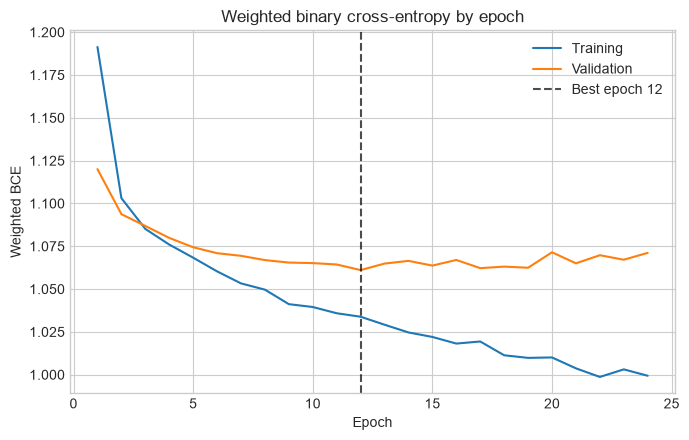

In [57]:
# Keep this training step aligned with the frozen method configuration.
plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(training_history["epoch"], training_history["training_weighted_bce"], label="Training")
ax.plot(training_history["epoch"], training_history["validation_weighted_bce"], label="Validation")
ax.axvline(best_epoch, color="black", linestyle="--", alpha=0.7, label=f"Best epoch {best_epoch}")
ax.set(title="Weighted binary cross-entropy by epoch", xlabel="Epoch", ylabel="Weighted BCE")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "training_validation_loss.png", dpi=180)
plt.show()

The training summary below reports the class weight, stopping point and restored validation checkpoint.

In [58]:
# Keep this training step aligned with the frozen method configuration.
display(Markdown(
    f"Training contains **{negative_count_train:,} negative** and **{positive_count_train:,} positive** "
    f"assessments, giving weight **{positive_class_weight:.4f}**. Early stopping ran "
    f"**{len(training_history)} epochs** and restored epoch **{best_epoch}**, with weighted validation BCE "
    f"**{best_validation_loss:.4f}**. Later epochs did not improve beyond the configured tolerance."
))

Training contains **38,864 negative** and **3,160 positive** assessments, giving weight **12.2987**. Early stopping ran **24 epochs** and restored epoch **12**, with weighted validation BCE **1.0611**. Later epochs did not improve beyond the configured tolerance.

# 9. Threshold selection

Probabilities require a threshold to create classes. Lower thresholds usually increase sensitivity and false positives; higher thresholds reduce alerts and can increase false negatives. Selection uses validation data only.

The restored model is evaluated without gradients and sigmoid converts logits to probabilities in stable row order.

In [59]:
# Preserve row order so saved probabilities remain aligned with assessment IDs.
def predict_probabilities(model_object: nn.Module, matrix: np.ndarray, batch_size: int = 2048) -> np.ndarray:
    model_object.eval()
    outputs = []
    dataset = TensorDataset(torch.from_numpy(matrix.astype(np.float32)))
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    with torch.no_grad():
        for (batch_x,) in loader:
            logits = model_object(batch_x.to(DEVICE))
            outputs.append(torch.sigmoid(logits).cpu().numpy())
    return np.concatenate(outputs)
validation_probabilities = predict_probabilities(model, X_validation)
validation_preview = split_frames['validation'][['assessment_id', target_column]].head().copy()
validation_preview['probability'] = validation_probabilities[:len(validation_preview)]
display(validation_preview)

,assessment_id,acute_rejection_within_30_days,probability
12,V32P-A000013,0,0.762287
13,V32P-A000014,0,0.701065
14,V32P-A000015,0,0.645605
15,V32P-A000016,0,0.593882
16,V32P-A000017,0,0.499511


The established grid is 0.05–0.95 by 0.01. Each row includes alert trade-offs and the complete validation confusion matrix.

In [60]:
# Compare thresholds using validation data only.
threshold_rows = []


In [61]:
# Calculate the established evaluation outputs without changing model selection.
for threshold in np.round(np.arange(0.05, 0.951, 0.01), 2):
    predictions = (validation_probabilities >= threshold).astype(np.int64)
    tn, fp, fn, tp = confusion_matrix(y_validation, predictions, labels=[0, 1]).ravel()
    threshold_rows.append({
        "threshold": float(threshold),
        "precision": precision_score(y_validation, predictions, zero_division=0),
        "recall": recall_score(y_validation, predictions, zero_division=0),
        "f1": f1_score(y_validation, predictions, zero_division=0),
        "specificity": tn / (tn + fp),
        "balanced_accuracy": balanced_accuracy_score(y_validation, predictions),
        "positive_prediction_rate": predictions.mean(),
        "true_negative": int(tn), "false_positive": int(fp),
        "false_negative": int(fn), "true_positive": int(tp),
        "distance_from_0_5": abs(float(threshold) - 0.5),
    })


In [62]:
validation_thresholds = pd.DataFrame(threshold_rows)
display(validation_thresholds.loc[validation_thresholds["threshold"].between(0.58, 0.66)])

,threshold,precision,recall,f1,specificity,balanced_accuracy,positive_prediction_rate,true_negative,false_positive,false_negative,true_positive,distance_from_0_5
53,0.58,0.138416,0.485800,0.215446,0.756822,0.621311,0.261237,6296,2023,344,325,0.08
54,0.59,0.143981,0.464873,0.219866,0.777738,0.621305,0.240320,6470,1849,358,311,0.09
55,0.60,0.150505,0.445441,0.224991,0.797812,0.621627,0.220294,6637,1682,371,298,0.10
56,0.61,0.158011,0.427504,0.230738,0.816805,0.622154,0.201380,6795,1524,383,286,0.11
57,0.62,0.162146,0.402093,0.231100,0.832913,0.617503,0.184579,6929,1390,400,269,0.12
58,0.63,0.162978,0.363229,0.225000,0.849982,0.606605,0.165888,7071,1248,426,243,0.13
59,0.64,0.171536,0.342302,0.228543,0.867051,0.604677,0.148531,7213,1106,440,229,0.14
60,0.65,0.178602,0.316891,0.228448,0.882798,0.599845,0.132065,7344,975,457,212,0.15
61,0.66,0.181303,0.286996,0.222222,0.895781,0.591388,0.117824,7452,867,477,192,0.16


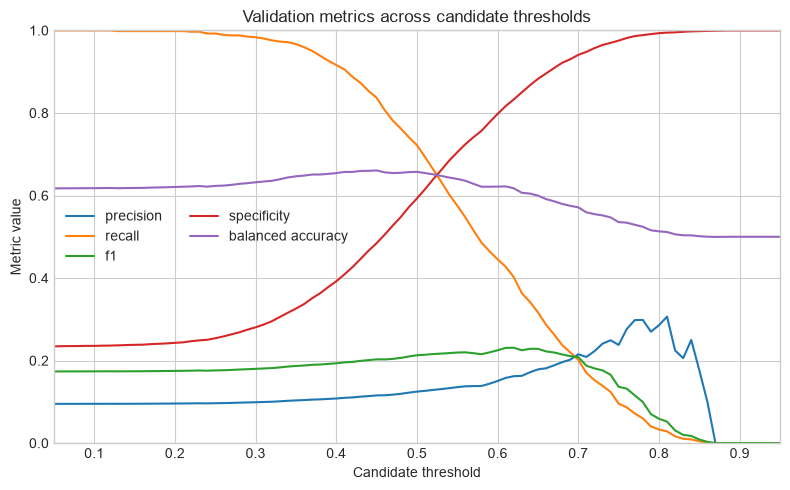

In [63]:
# Calculate the established evaluation outputs without changing model selection.
fig, ax = plt.subplots(figsize=(8, 5))
for metric in ["precision", "recall", "f1", "specificity", "balanced_accuracy"]:
    ax.plot(validation_thresholds["threshold"], validation_thresholds[metric], label=metric.replace("_", " "))
ax.set(title="Validation metrics across candidate thresholds", xlabel="Candidate threshold", ylabel="Metric value", xlim=(0.05, 0.95), ylim=(0, 1))
ax.legend(ncol=2)
fig.tight_layout()
plt.show()

The deterministic rule maximises validation F1, then balanced accuracy, then closeness to 0.50, then prefers the lower threshold. The assertion stops execution if the rule no longer selects 0.62. Test data are absent.

In [64]:
# Apply the frozen tie-break rule and confirm it still selects 0.62.
selection_order = validation_thresholds.sort_values(
    ["f1", "balanced_accuracy", "distance_from_0_5", "threshold"],
    ascending=[False, False, True, True], kind="mergesort",
)
selected_threshold = float(selection_order.iloc[0]["threshold"])
assert selected_threshold == 0.62
validation_thresholds["selected"] = validation_thresholds["threshold"].eq(selected_threshold)
validation_thresholds.to_csv(RESULT_DIR / "validation_thresholds.csv", index=False)
display(selection_order.head(10))
print(f"Selected threshold from validation only: {selected_threshold:.2f}")

,threshold,precision,recall,f1,specificity,balanced_accuracy,positive_prediction_rate,true_negative,false_positive,false_negative,true_positive,distance_from_0_5
57,0.62,0.162146,0.402093,0.231100,0.832913,0.617503,0.184579,6929,1390,400,269,0.12
56,0.61,0.158011,0.427504,0.230738,0.816805,0.622154,0.201380,6795,1524,383,286,0.11
59,0.64,0.171536,0.342302,0.228543,0.867051,0.604677,0.148531,7213,1106,440,229,0.14
60,0.65,0.178602,0.316891,0.228448,0.882798,0.599845,0.132065,7344,975,457,212,0.15
58,0.63,0.162978,0.363229,0.225000,0.849982,0.606605,0.165888,7071,1248,426,243,0.13
55,0.60,0.150505,0.445441,0.224991,0.797812,0.621627,0.220294,6637,1682,371,298,0.10
61,0.66,0.181303,0.286996,0.222222,0.895781,0.591388,0.117824,7452,867,477,192,0.16
51,0.56,0.137646,0.547085,0.219952,0.724366,0.635726,0.295839,6026,2293,303,366,0.06
54,0.59,0.143981,0.464873,0.219866,0.777738,0.621305,0.240320,6470,1849,358,311,0.09
62,0.67,0.188437,0.263079,0.219588,0.908883,0.585981,0.103916,7561,758,493,176,0.17


Selected threshold from validation only: 0.62


The selected-threshold summary below reports the validation result and confirms that test data were not used.

In [65]:
# Keep this stage separate so its inputs and checks remain easy to audit.
selected_validation = validation_thresholds.loc[validation_thresholds["selected"]].iloc[0]
display(Markdown(
    f"Threshold **{selected_threshold:.2f}** ranks first under the pre-specified validation rule, with F1 "
    f"**{selected_validation['f1']:.4f}** and balanced accuracy "
    f"**{selected_validation['balanced_accuracy']:.4f}**. No test result influenced selection."
))

Threshold **0.62** ranks first under the pre-specified validation rule, with F1 **0.2311** and balanced accuracy **0.6175**. No test result influenced selection.

# 10. Test evaluation

The held-out test set is evaluated once after selection. The auditable table retains IDs, targets, probabilities and frozen-threshold classes.

In [66]:
# Calculate one consistent metric set for validation, test and readback checks.
def binary_metrics(y_true: np.ndarray, probabilities: np.ndarray, threshold: float) -> dict[str, float | int]:
    predictions = (probabilities >= threshold).astype(np.int64)
    tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()
    return {
        "n": int(len(y_true)),
        "positive_count": int(np.sum(y_true)),
        "prevalence": float(np.mean(y_true)),
        "threshold": float(threshold),
        "pr_auc": float(average_precision_score(y_true, probabilities)),
        "auroc": float(roc_auc_score(y_true, probabilities)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, predictions)),
        "f1": float(f1_score(y_true, predictions, zero_division=0)),
        "binary_cross_entropy": float(log_loss(y_true, probabilities, labels=[0, 1])),
        "precision": float(precision_score(y_true, predictions, zero_division=0)),
        "recall": float(recall_score(y_true, predictions, zero_division=0)),
        "specificity": float(tn / (tn + fp)) if (tn + fp) else float("nan"),
        "accuracy": float(accuracy_score(y_true, predictions)),
        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp),
        "positive_prediction_rate": float(np.mean(predictions)),
    }

In [67]:
# This is the first and only performance evaluation on the untouched test set.
model_probabilities = predict_probabilities(model, X_test)
canonical_probabilities = np.asarray(model_probabilities, dtype=np.float64)
test_probabilities = canonical_probabilities
test_predictions_binary = (canonical_probabilities >= selected_threshold).astype(np.int64)
test_metric_values = binary_metrics(y_test, canonical_probabilities, selected_threshold)
test_metrics = pd.DataFrame([test_metric_values])
test_metrics.to_csv(RESULT_DIR / "test_metrics.csv", index=False, float_format="%.17g")

test_predictions = split_frames["test"][
    ["assessment_id", "recipient_id", "donor_id", "days_since_transplant"]
].copy()
test_predictions["target"] = y_test.astype(np.int64)
test_predictions["probability"] = canonical_probabilities
test_predictions["prediction"] = test_predictions_binary
test_predictions["threshold"] = selected_threshold
test_predictions.to_csv(RESULT_DIR / "test_predictions.csv", index=False, float_format="%.17g")


In [68]:

display(test_metrics.T.rename(columns={0: "test_value"}))
display(test_predictions.head())


,test_value
n,8988.000000
positive_count,665.000000
prevalence,0.073988
threshold,0.620000
pr_auc,0.168861
auroc,0.732132
balanced_accuracy,0.630389
f1,0.244579
binary_cross_entropy,0.575092
precision,0.171846


,assessment_id,recipient_id,donor_id,days_since_transplant,target,probability,prediction,threshold
24,V32P-A000025,V32P-R000005,V32P-DL001186,7,0,0.539234,0,0.62
25,V32P-A000026,V32P-R000005,V32P-DL001186,14,0,0.422118,0,0.62
26,V32P-A000027,V32P-R000005,V32P-DL001186,30,0,0.356694,0,0.62
27,V32P-A000028,V32P-R000005,V32P-DL001186,60,0,0.520263,0,0.62
28,V32P-A000029,V32P-R000005,V32P-DL001186,90,0,0.375545,0,0.62


PR-AUC and AUROC use probabilities; balanced accuracy and F1 use thresholded classes. Evaluation BCE is standard unweighted BCE, distinct from weighted training loss.

In [69]:
display(pd.Series({name: test_metric_values[name] for name in ['pr_auc', 'auroc', 'balanced_accuracy', 'f1', 'binary_cross_entropy']}, name='test value').to_frame())

,test value
pr_auc,0.168861
auroc,0.732132
balanced_accuracy,0.630389
f1,0.244579
binary_cross_entropy,0.575092


Accuracy is not interpreted alone: with few positive assessments, favouring the negative class can produce high accuracy.

In [70]:
display(pd.Series({name: test_metric_values[name] for name in ['precision', 'recall', 'specificity', 'accuracy', 'positive_prediction_rate']}, name='test value').to_frame())

,test value
precision,0.171846
recall,0.424060
specificity,0.836718
accuracy,0.806186
positive_prediction_rate,0.182577


The four counts are independently used to reconstruct every threshold-dependent metric before plotting.

In [71]:
# Reconstruct thresholded counts to verify the reported confusion matrix.
matrix = confusion_matrix(y_test, test_predictions_binary, labels=[0, 1])
tn, fp, fn, tp = matrix.ravel()
assert (int(tn), int(fp), int(fn), int(tp)) == (6_964, 1_359, 383, 282)
reconstructed = {
    "precision": tp / (tp + fp), "recall": tp / (tp + fn),
    "specificity": tn / (tn + fp), "accuracy": (tn + tp) / matrix.sum(),
    "f1": 2 * tp / (2 * tp + fp + fn),
    "balanced_accuracy": ((tp / (tp + fn)) + (tn / (tn + fp))) / 2,
}
for metric, value in reconstructed.items():
    assert np.isclose(value, test_metric_values[metric], atol=1e-12, rtol=0)

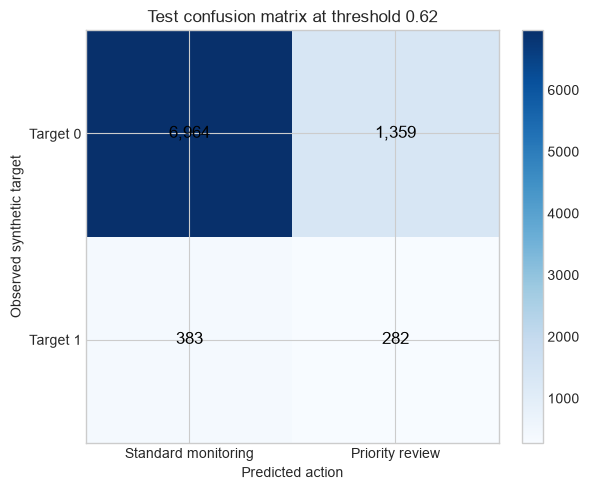

In [72]:
# Calculate the established evaluation outputs without changing model selection.
matrix = confusion_matrix(y_test, test_predictions_binary, labels=[0, 1])
fig, ax = plt.subplots(figsize=(6.5, 5))
image = ax.imshow(matrix, cmap="Blues")
for (row, column), value in np.ndenumerate(matrix):
    ax.text(column, row, f"{value:,}", ha="center", va="center", color="black", fontsize=12)
ax.set_xticks([0, 1], ["Standard monitoring", "Priority review"])
ax.set_yticks([0, 1], ["Target 0", "Target 1"])
ax.set(title=f"Test confusion matrix at threshold {selected_threshold:.2f}", xlabel="Predicted action", ylabel="Observed synthetic target")
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "test_confusion_matrix.png", dpi=180)
plt.show()

The precision–recall curve is compared with positive prevalence, which is especially relevant under imbalance. ROC is compared with random ranking.

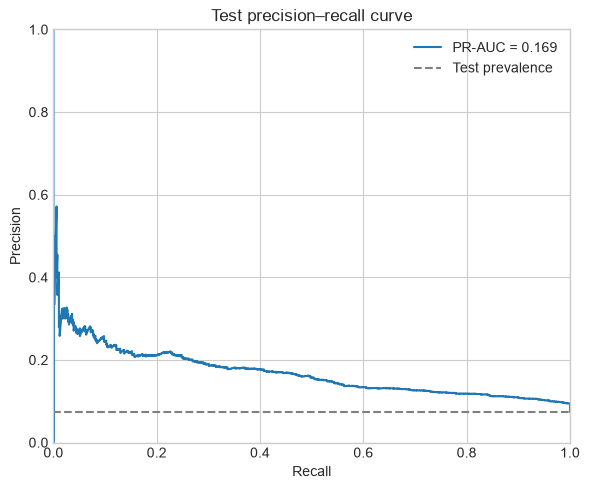

In [73]:
# Use PR-AUC to assess ranking under the uncommon positive class.
precision_curve, recall_curve, _ = precision_recall_curve(y_test, test_probabilities)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(recall_curve, precision_curve, label=f"PR-AUC = {test_metric_values['pr_auc']:.3f}")
ax.axhline(y_test.mean(), color="grey", linestyle="--", label="Test prevalence")
ax.set(title="Test precision–recall curve", xlabel="Recall", ylabel="Precision", xlim=(0, 1), ylim=(0, 1))
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "test_precision_recall_curve.png", dpi=180)
plt.show()

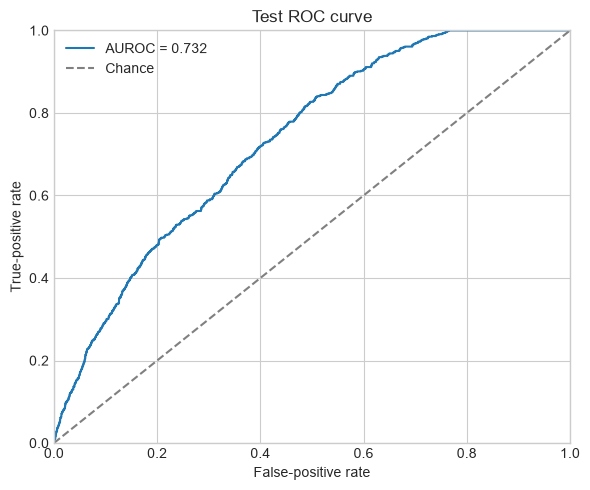

In [74]:
# Use AUROC as a threshold-independent ranking check.
false_positive_rate, true_positive_rate, _ = roc_curve(y_test, test_probabilities)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(false_positive_rate, true_positive_rate, label=f"AUROC = {test_metric_values['auroc']:.3f}")
ax.plot([0, 1], [0, 1], color="grey", linestyle="--", label="Chance")
ax.set(title="Test ROC curve", xlabel="False-positive rate", ylabel="True-positive rate", xlim=(0, 1), ylim=(0, 1))
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "test_roc_curve.png", dpi=180)
plt.show()

Interpretation is restricted to this generated held-out split. Established day and subgroup diagnostics are regenerated for reference; subgroup values are exploratory, not causal claims or tuned rules.

In [75]:
# Examine assessment-day variation without using it to tune the model.
day_rows = []


In [76]:
# Calculate the established evaluation outputs without changing model selection.
for day, indices in split_frames["test"].groupby("days_since_transplant").indices.items():
    day_indices = np.asarray(indices)
    day_y = y_test[day_indices]
    day_probability = test_probabilities[day_indices]
    classes = np.unique(day_y)
    if len(classes) == 2:
        row = binary_metrics(day_y, day_probability, selected_threshold)
        row["metric_status"] = "all binary metrics available"
    else:
        prediction = (day_probability >= selected_threshold).astype(np.int64)
        tn, fp, fn, tp = confusion_matrix(day_y, prediction, labels=[0, 1]).ravel()
        row = {
            "n": len(day_y), "positive_count": int(day_y.sum()),
            "prevalence": float(day_y.mean()), "threshold": selected_threshold,
            "pr_auc": np.nan, "auroc": np.nan, "balanced_accuracy": np.nan,
            "f1": np.nan, "precision": np.nan, "recall": np.nan,
            "binary_cross_entropy": log_loss(day_y, day_probability, labels=[0, 1]),
            "specificity": float(tn / (tn + fp)) if (tn + fp) else np.nan,
            "accuracy": accuracy_score(day_y, prediction),
            "positive_prediction_rate": float(prediction.mean()),
            "true_negative": int(tn), "false_positive": int(fp),
            "false_negative": int(fn), "true_positive": int(tp),
            "metric_status": "single target class; positive-class metrics unavailable",
        }
    row["classes_present"] = ",".join(str(int(value)) for value in classes)
    row["days_since_transplant"] = int(day)
    day_rows.append(row)


In [77]:
metrics_by_assessment_day = pd.DataFrame(day_rows).sort_values("days_since_transplant")
metrics_by_assessment_day.to_csv(RESULT_DIR / "metrics_by_assessment_day.csv", index=False)
display(metrics_by_assessment_day)

,n,positive_count,prevalence,threshold,pr_auc,auroc,balanced_accuracy,f1,binary_cross_entropy,precision,...,specificity,accuracy,true_negative,false_positive,false_negative,true_positive,positive_prediction_rate,metric_status,classes_present,days_since_transplant
0,1498,165,0.110147,0.62,0.213459,0.684257,0.641631,0.280566,0.836781,0.178105,...,0.622656,0.626836,830,503,56,109,0.408545,all binary metrics available,"0,1",7
1,1498,165,0.110147,0.62,0.219223,0.657333,0.602594,0.265655,0.732201,0.193370,...,0.780945,0.741656,1041,292,95,70,0.241656,all binary metrics available,"0,1",14
2,1498,130,0.086782,0.62,0.168468,0.667566,0.604780,0.236659,0.707330,0.169435,...,0.817251,0.780374,1118,250,79,51,0.200935,all binary metrics available,"0,1",30
3,1498,80,0.053405,0.62,0.086271,0.664677,0.584926,0.159509,0.647563,0.105691,...,0.844852,0.817089,1198,220,54,26,0.164219,all binary metrics available,"0,1",60
4,1498,125,0.083445,0.62,0.177623,0.683554,0.569768,0.212245,0.522197,0.216667,...,0.931537,0.871162,1279,94,99,26,0.080107,all binary metrics available,"0,1",90
5,1498,0,0.000000,0.62,NaN,NaN,NaN,NaN,0.004480,NaN,...,1.000000,1.000000,1498,0,0,0,0.000000,single target class; positive-class metrics un...,0,180


In [78]:
# Treat subgroup summaries as descriptive checks, not causal comparisons.
def safe_subgroup_metrics(frame: pd.DataFrame, group_column: str) -> list[dict]:
    rows = []
    for value, indices in frame.groupby(group_column, dropna=False).indices.items():
        positions = np.asarray(indices)
        group_y = y_test[positions]
        group_probabilities = test_probabilities[positions]
        predictions = (group_probabilities >= selected_threshold).astype(np.int64)
        tn, fp, fn, tp = confusion_matrix(group_y, predictions, labels=[0, 1]).ravel()
        rows.append({
            "diagnostic_label": "EXPLORATORY_ONLY",
            "subgroup_dimension": group_column,
            "subgroup_value": str(value),
            "n": int(len(group_y)),
            "positive_count": int(group_y.sum()),
            "prevalence": float(group_y.mean()),
            "pr_auc": float(average_precision_score(group_y, group_probabilities)) if group_y.sum() else float("nan"),
            "auroc": float(roc_auc_score(group_y, group_probabilities)) if len(np.unique(group_y)) == 2 else float("nan"),
            "f1": float(f1_score(group_y, predictions, zero_division=0)),
            "recall": float(recall_score(group_y, predictions, zero_division=0)),
            "specificity": float(tn / (tn + fp)) if (tn + fp) else float("nan"),
            "positive_prediction_rate": float(predictions.mean()),
            "true_negative": int(tn),
            "false_positive": int(fp),
            "false_negative": int(fn),
            "true_positive": int(tp),
        })
    return rows

In [79]:
# Compare subgroup utility descriptively after final test evaluation.
subgroup_rows = []
for subgroup_column in [
    "donor_type",
    "kidney_failure_cause",
    "recipient_sex",
    "recipient_ethnicity",
    "recipient_region",
]:
    subgroup_rows.extend(safe_subgroup_metrics(split_frames["test"], subgroup_column))
exploratory_subgroup_metrics = pd.DataFrame(subgroup_rows)
exploratory_subgroup_metrics.to_csv(RESULT_DIR / "exploratory_subgroup_metrics.csv", index=False)

display(exploratory_subgroup_metrics.head(12))
print("Subgroup results are exploratory diagnostics, not tuned decision rules or causal claims.")

,diagnostic_label,subgroup_dimension,subgroup_value,n,positive_count,prevalence,pr_auc,auroc,f1,recall,specificity,positive_prediction_rate,true_negative,false_positive,false_negative,true_positive
0,EXPLORATORY_ONLY,donor_type,Deceased,5316,428,0.080512,0.169266,0.716374,0.241611,0.420561,0.819558,0.199774,4006,882,248,180
1,EXPLORATORY_ONLY,donor_type,Living,3672,237,0.064542,0.169218,0.748012,0.250000,0.430380,0.861135,0.157680,2958,477,135,102
2,EXPLORATORY_ONLY,kidney_failure_cause,Diabetic kidney disease,1914,130,0.067921,0.150938,0.708576,0.193548,0.323077,0.853139,0.158830,1522,262,88,42
3,EXPLORATORY_ONLY,kidney_failure_cause,Glomerulonephritis,1776,139,0.078266,0.187390,0.748461,0.276923,0.453237,0.845449,0.177928,1384,253,76,63
4,EXPLORATORY_ONLY,kidney_failure_cause,Hypertensive kidney disease,1872,145,0.077457,0.147602,0.714546,0.225191,0.406897,0.814708,0.202457,1407,320,86,59
5,EXPLORATORY_ONLY,kidney_failure_cause,Other,1638,137,0.083639,0.215671,0.764099,0.277087,0.569343,0.768155,0.260073,1153,348,59,78
6,EXPLORATORY_ONLY,kidney_failure_cause,Polycystic kidney disease,1788,114,0.063758,0.186665,0.714729,0.242424,0.350877,0.894863,0.120805,1498,176,74,40
7,EXPLORATORY_ONLY,recipient_sex,Female,4608,344,0.074653,0.165629,0.725555,0.251773,0.412791,0.849437,0.170139,3622,642,202,142
8,EXPLORATORY_ONLY,recipient_sex,Male,4380,321,0.073288,0.175478,0.739025,0.237691,0.436137,0.823356,0.195662,3342,717,181,140
9,EXPLORATORY_ONLY,recipient_ethnicity,Asian,1878,155,0.082535,0.201959,0.756037,0.281385,0.419355,0.859547,0.163472,1481,242,90,65


Subgroup results are exploratory diagnostics, not tuned decision rules or causal claims.


In [80]:
# Calculate the established evaluation outputs without changing model selection.
display(Markdown(
    f"PR-AUC (**{test_metric_values['pr_auc']:.3f}**) exceeds test assessment prevalence "
    f"(**{test_metric_values['prevalence']:.3f}**). AUROC (**{test_metric_values['auroc']:.3f}**) indicates "
    f"moderate ranking discrimination in this generated sample. Positive-class precision "
    f"(**{test_metric_values['precision']:.3f}**) and recall (**{test_metric_values['recall']:.3f}**) remain "
    f"limited. This is a controlled research baseline, not evidence of clinical readiness."
))

PR-AUC (**0.169**) exceeds test assessment prevalence (**0.074**). AUROC (**0.732**) indicates moderate ranking discrimination in this generated sample. Positive-class precision (**0.172**) and recall (**0.424**) remain limited. This is a controlled research baseline, not evidence of clinical readiness.

The final test summary below reports the fixed-threshold results and the day-180 temporal-coverage limitation.

In [81]:
# Leave single-class day metrics undefined rather than inventing scores.
day_180 = metrics_by_assessment_day.set_index("days_since_transplant").loc[180]
assert int(day_180["positive_count"]) == 0
assert day_180[["pr_auc", "auroc", "balanced_accuracy", "f1", "recall"]].isna().all()
display(Markdown(
    f"On **{test_metric_values['n']:,} held-out assessments**, PR-AUC was "
    f"**{test_metric_values['pr_auc']:.6f}**, AUROC **{test_metric_values['auroc']:.6f}**, balanced "
    f"accuracy **{test_metric_values['balanced_accuracy']:.6f}**, F1 **{test_metric_values['f1']:.6f}** "
    f"and unweighted BCE **{test_metric_values['binary_cross_entropy']:.6f}**. Day 180 contained "
    "no positive targets, so its AUROC, PR-AUC, balanced accuracy, positive-class recall and F1 are "
    "unavailable. This temporal-coverage limitation follows from the controlled event and assessment "
    "schedule; it does not alter the correctly calculated overall held-out test metrics."
))

On **8,988 held-out assessments**, PR-AUC was **0.168861**, AUROC **0.732132**, balanced accuracy **0.630389**, F1 **0.244579** and unweighted BCE **0.575092**. Day 180 contained no positive targets, so its AUROC, PR-AUC, balanced accuracy, positive-class recall and F1 are unavailable. This temporal-coverage limitation follows from the controlled event and assessment schedule; it does not alter the correctly calculated overall held-out test metrics.

# 11. Save and verify artefacts

Established checkpoint, preprocessor, feature-order and configuration filenames are preserved for later notebooks.

In [82]:
# Save the fitted training-only preprocessor for every later experiment.
joblib.dump(preprocessor, MODEL_DIR / 'baseline_preprocessor.joblib')
(MODEL_DIR / 'processed_feature_order.json').write_text(json.dumps({'processed_features': processed_feature_order}, indent=2) + '\n', encoding='utf-8')

1085

In [83]:
# Store architecture details with the weights so reloads are unambiguous.
model_checkpoint = {
    "model_state_dict": model.state_dict(),
    "input_dim": int(X_train.shape[1]),
    "hidden_dims": list(HIDDEN_DIMS),
    "dropout": DROPOUT,
    "selected_threshold": selected_threshold,
    "seed": SEED,
    "best_epoch": best_epoch,
}
torch.save(model_checkpoint, MODEL_DIR / "baseline_model.pt")

In [84]:
# Record the complete frozen configuration beside the checkpoint.
model_configuration = {
    "model_name": "BaselineMLP",
    "task": "acute rejection within 30 days of an assessment",
    "target_column": target_column,
    "classifier_features_source": "data/final/classifier_feature_list.json",
    "classifier_features": classifier_features,
    "input_dim_processed": int(X_train.shape[1]),
    "hidden_dims": list(HIDDEN_DIMS),
    "dropout": DROPOUT,
    "parameter_count": parameter_count,
    "loss": "BCEWithLogitsLoss",
    "training_positive_class_weight": positive_class_weight,
    "optimizer": "AdamW",
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "batch_size": BATCH_SIZE,
    "maximum_epochs": MAX_EPOCHS,
    "early_stopping_patience": PATIENCE,
    "best_epoch": best_epoch,
    "best_validation_weighted_bce": best_validation_loss,
    "threshold": selected_threshold,
    "threshold_selection": "maximize validation F1, then balanced accuracy, then closest to 0.50, then lower threshold",
    "seed": SEED,
    "device": str(DEVICE),
}


In [85]:
(MODEL_DIR / "model_configuration.json").write_text(
    json.dumps(model_configuration, indent=2) + "\n", encoding="utf-8"
)

1327

History, thresholds, predictions, metrics and four figures were saved where produced. This inventory checks the established files without creating duplicates.

In [86]:
# Verify every established artifact exists before declaring the run complete.
expected_artifacts = [
    PROCESSED_DIR / "split_assignments.csv", PROCESSED_DIR / "training_assessments.csv",
    PROCESSED_DIR / "validation_assessments.csv", PROCESSED_DIR / "test_assessments.csv",
    MODEL_DIR / "baseline_model.pt", MODEL_DIR / "baseline_preprocessor.joblib",
    MODEL_DIR / "model_configuration.json", MODEL_DIR / "processed_feature_order.json",
    RESULT_DIR / "training_history.csv", RESULT_DIR / "validation_thresholds.csv",
    RESULT_DIR / "test_predictions.csv", RESULT_DIR / "test_metrics.csv",
    FIGURE_DIR / "training_validation_loss.png", FIGURE_DIR / "test_confusion_matrix.png",
    FIGURE_DIR / "test_precision_recall_curve.png", FIGURE_DIR / "test_roc_curve.png",
]
artifact_table = pd.DataFrame({
    "artifact": [path.relative_to(SUBMISSION_ROOT).as_posix() for path in expected_artifacts],
    "exists": [path.is_file() for path in expected_artifacts],
})
assert artifact_table["exists"].all()


In [87]:
display(artifact_table)

,artifact,exists
0,processed_data/split_assignments.csv,True
1,processed_data/training_assessments.csv,True
2,processed_data/validation_assessments.csv,True
3,processed_data/test_assessments.csv,True
4,models/baseline/baseline_model.pt,True
5,models/baseline/baseline_preprocessor.joblib,True
6,models/baseline/model_configuration.json,True
7,models/baseline/processed_feature_order.json,True
8,results/baseline/training_history.csv,True
9,results/baseline/validation_thresholds.csv,True


The preprocessor and model are reloaded independently. Probabilities use `1e-7` tolerance; metrics recalculated from the saved prediction CSV use `1e-8`.

In [88]:
# Reload on CPU so verification does not depend on accelerator availability.
def load_checkpoint(path: Path) -> dict:
    try:
        return torch.load(path, map_location=DEVICE, weights_only=True)
    except TypeError:
        return torch.load(path, map_location=DEVICE)


reloaded_preprocessor = joblib.load(MODEL_DIR / "baseline_preprocessor.joblib")
reloaded_checkpoint = load_checkpoint(MODEL_DIR / "baseline_model.pt")
reloaded_model = BaselineMLP(
    reloaded_checkpoint["input_dim"],
    tuple(reloaded_checkpoint["hidden_dims"]),
    reloaded_checkpoint["dropout"],
).to(DEVICE)
reloaded_model.load_state_dict(reloaded_checkpoint["model_state_dict"])

<All keys matched successfully>

In [89]:
# Check that saved predictions still refer to the same test rows and targets.
saved_test_rows = pd.read_csv(PROCESSED_DIR / "test_assessments.csv")
reloaded_test_matrix = reloaded_preprocessor.transform(
    saved_test_rows[classifier_features]
).astype(np.float32)
reproduced_probabilities = np.asarray(
    predict_probabilities(reloaded_model, reloaded_test_matrix), dtype=np.float64
)
saved_predictions = pd.read_csv(RESULT_DIR / "test_predictions.csv")
saved_probability_array = saved_predictions["probability"].to_numpy(dtype=np.float64)
maximum_probability_difference = float(
    np.max(np.abs(reproduced_probabilities - saved_probability_array))
)
probability_reproduction_pass = bool(np.allclose(
    saved_probability_array, reproduced_probabilities, rtol=1e-7, atol=1e-7
))


In [90]:
# Recalculate metrics from disk rather than trusting in-memory values.
saved_y = saved_predictions["target"].to_numpy(dtype=np.int64)
saved_probabilities = saved_predictions["probability"].to_numpy(dtype=np.float64)
saved_binary = saved_predictions["prediction"].to_numpy(dtype=np.int64)
saved_threshold = float(saved_predictions["threshold"].iloc[0])
derived_binary = (saved_probabilities >= saved_threshold).astype(np.int64)
tn, fp, fn, tp = confusion_matrix(saved_y, saved_binary, labels=[0, 1]).ravel()


In [91]:
# Load frozen inputs so this stage reuses rather than regenerates earlier evidence.
independent_metrics = {
    "n": len(saved_y), "positive_count": int(saved_y.sum()), "prevalence": saved_y.mean(),
    "threshold": saved_threshold, "pr_auc": average_precision_score(saved_y, saved_probabilities),
    "auroc": roc_auc_score(saved_y, saved_probabilities),
    "balanced_accuracy": balanced_accuracy_score(saved_y, saved_binary),
    "f1": f1_score(saved_y, saved_binary, zero_division=0),
    "binary_cross_entropy": log_loss(saved_y, saved_probabilities, labels=[0, 1]),
    "precision": precision_score(saved_y, saved_binary, zero_division=0),
    "recall": recall_score(saved_y, saved_binary, zero_division=0),
    "specificity": tn / (tn + fp), "accuracy": accuracy_score(saved_y, saved_binary),
    "true_negative": int(tn), "false_positive": int(fp), "false_negative": int(fn),
    "true_positive": int(tp), "positive_prediction_rate": saved_binary.mean(),
}
saved_metric_row = pd.read_csv(RESULT_DIR / "test_metrics.csv").iloc[0]
integer_metrics = {"n", "positive_count", "true_negative", "false_positive", "false_negative", "true_positive"}


In [92]:
# Calculate the established evaluation outputs without changing model selection.
diagnostic_rows = []
for metric_name, recalculated_value in independent_metrics.items():
    saved_value = saved_metric_row[metric_name]
    tolerance = 0.0 if metric_name in integer_metrics else 1e-8
    difference = abs(float(saved_value) - float(recalculated_value))
    diagnostic_rows.append({"metric_name": metric_name, "saved_value": saved_value,
        "recalculated_value": recalculated_value, "absolute_difference": difference,
        "required_tolerance": tolerance, "pass": difference <= tolerance})
metric_diagnostic = pd.DataFrame(diagnostic_rows)
metric_diagnostic.to_csv(RESULT_DIR / "metric_reproduction_diagnostic.csv", index=False, float_format="%.17g")
metric_reproduction_pass = bool(metric_diagnostic["pass"].all())
threshold_predictions_match = bool(np.array_equal(saved_binary, derived_binary))
identifier_columns = ["assessment_id", "recipient_id", "donor_id", "days_since_transplant"]
saved_identifiers_match = bool(saved_predictions[identifier_columns].equals(saved_test_rows[identifier_columns]))
saved_targets_match = bool(np.array_equal(saved_y, saved_test_rows[target_column].to_numpy(dtype=np.int64)))


In [93]:
display(metric_diagnostic)


,metric_name,saved_value,recalculated_value,absolute_difference,required_tolerance,pass
0,n,8988.000000,8988.000000,0.000000e+00,0.000000e+00,True
1,positive_count,665.000000,665.000000,0.000000e+00,0.000000e+00,True
2,prevalence,0.073988,0.073988,2.808474e-09,1.000000e-08,True
3,threshold,0.620000,0.620000,0.000000e+00,1.000000e-08,True
4,pr_auc,0.168861,0.168861,8.326673e-17,1.000000e-08,True
5,auroc,0.732132,0.732132,0.000000e+00,1.000000e-08,True
6,balanced_accuracy,0.630389,0.630389,0.000000e+00,1.000000e-08,True
7,f1,0.244579,0.244579,0.000000e+00,1.000000e-08,True
8,binary_cross_entropy,0.575092,0.575092,1.110223e-16,1.000000e-08,True
9,precision,0.171846,0.171846,5.551115e-17,1.000000e-08,True


In [94]:
# Combine structural and numerical checks into one final verification table.
confusion_matrix_reproduced = bool(
    (int(tn), int(fp), int(fn), int(tp)) ==
    tuple(int(saved_metric_row[name]) for name in
          ["true_negative", "false_positive", "false_negative", "true_positive"])
)


In [95]:
# Calculate the established evaluation outputs without changing model selection.
verification_table = pd.DataFrame([
    {"check": "Preserved split membership", "pass": preserved_split_membership_identical},
    {"check": "Best validation model restored", "pass": best_model_restored},
    {"check": "Preprocessor reload", "pass": reloaded_test_matrix.shape == X_test.shape},
    {"check": "Model reload", "pass": reloaded_checkpoint["input_dim"] == X_test.shape[1]},
    {"check": "Saved identifiers and targets", "pass": saved_identifiers_match and saved_targets_match},
    {"check": "Thresholded predictions", "pass": threshold_predictions_match},
    {"check": "Probability reproduction (atol=rtol=1e-7)", "pass": probability_reproduction_pass},
    {"check": "Metric reproduction (1e-8)", "pass": metric_reproduction_pass},
    {"check": "Confusion-matrix reproduction", "pass": confusion_matrix_reproduced},
    {"check": "Architecture and parameter count", "pass": X_test.shape[1] == 24 and parameter_count == 3713},
    {"check": "Selected threshold is 0.62", "pass": saved_threshold == selected_threshold == 0.62},
])
all_verification_checks_pass = bool(verification_table["pass"].all())
verification_table["status"] = verification_table["pass"].map({True: "PASS", False: "FAIL"})


In [96]:
display(verification_table.drop(columns="pass"))
print(f"Maximum probability difference: {maximum_probability_difference:.3e}")
assert all_verification_checks_pass


,check,status
0,Preserved split membership,PASS
1,Best validation model restored,PASS
2,Preprocessor reload,PASS
3,Model reload,PASS
4,Saved identifiers and targets,PASS
5,Thresholded predictions,PASS
6,Probability reproduction (atol=rtol=1e-7),PASS
7,Metric reproduction (1e-8),PASS
8,Confusion-matrix reproduction,PASS
9,Architecture and parameter count,PASS


Maximum probability difference: 1.110e-16


In [97]:
# Save the evidence needed to reproduce and audit this frozen baseline.
reproducibility_report = {
    "seed": SEED, "device": str(DEVICE), "python_version": platform.python_version(),
    "package_versions": {
        "numpy": np.__version__, "pandas": pd.__version__,
        "scikit_learn": sklearn.__version__, "torch": torch.__version__,
        "joblib": joblib.__version__,
    },
    "deterministic_algorithms": True,
    "preserved_first_run_split_membership_identical": preserved_split_membership_identical,
    "best_validation_model_restored": best_model_restored,
    "preprocessor_reloaded": bool(reloaded_test_matrix.shape == X_test.shape),
    "model_reloaded": bool(reloaded_checkpoint["input_dim"] == X_test.shape[1]),
    "probabilities_reproduced": probability_reproduction_pass,
    "maximum_probability_difference": maximum_probability_difference,
    "metrics_independently_recalculated": metric_reproduction_pass,
    "confusion_matrix_reproduced": confusion_matrix_reproduced,
    "saved_identifiers_and_targets_match": saved_identifiers_match and saved_targets_match,
    "test_used_once_after_selection": True, "network_requests": 0,
}


In [98]:
(RESULT_DIR / "reproducibility_report.json").write_text(
    json.dumps(reproducibility_report, indent=2) + "\n", encoding="utf-8"
)

705

Later notebooks should load these fixed paths rather than reconstruct a different baseline.

In [99]:
# Calculate the established evaluation outputs without changing model selection.
display(pd.Series({
    "model": (MODEL_DIR / "baseline_model.pt").relative_to(SUBMISSION_ROOT).as_posix(),
    "preprocessor": (MODEL_DIR / "baseline_preprocessor.joblib").relative_to(SUBMISSION_ROOT).as_posix(),
    "permanent splits": (PROCESSED_DIR / "split_assignments.csv").relative_to(SUBMISSION_ROOT).as_posix(),
    "selected threshold": selected_threshold,
    "metrics": (RESULT_DIR / "test_metrics.csv").relative_to(SUBMISSION_ROOT).as_posix(),
    "predictions": (RESULT_DIR / "test_predictions.csv").relative_to(SUBMISSION_ROOT).as_posix(),
}).to_frame("value"))

,value
model,models/baseline/baseline_model.pt
preprocessor,models/baseline/baseline_preprocessor.joblib
permanent splits,processed_data/split_assignments.csv
selected threshold,0.62
metrics,results/baseline/test_metrics.csv
predictions,results/baseline/test_predictions.csv


In [100]:
# Re-derive acceptance values independently before marking the run complete.
training_positive_count = int(np.count_nonzero(y_train))
training_negative_count = int(len(y_train) - training_positive_count)
derived_positive_class_weight = training_negative_count / training_positive_count
acceptance_table = pd.DataFrame([
    {"requirement": "Architecture 24 to 64 to 32 to 1",
     "pass": X_train.shape[1] == 24 and HIDDEN_DIMS == (64, 32)},
    {"requirement": "Parameter count 3,713", "pass": parameter_count == 3_713},
    {"requirement": "Positive-class weight derived from integer training-target counts",
     "pass": positive_class_weight == derived_positive_class_weight},
    {"requirement": "Threshold selected from validation is 0.62", "pass": selected_threshold == 0.62},
    {"requirement": "Best validation model restored", "pass": best_model_restored},
    {"requirement": "All save/reload verification checks passed", "pass": all_verification_checks_pass},
])
acceptance_table["status"] = acceptance_table["pass"].map({True: "PASS", False: "FAIL"})
display(acceptance_table.drop(columns="pass"))


,requirement,status
0,Architecture 24 to 64 to 32 to 1,PASS
1,"Parameter count 3,713",PASS
2,Positive-class weight derived from integer tra...,PASS
3,Threshold selected from validation is 0.62,PASS
4,Best validation model restored,PASS
5,All save/reload verification checks passed,PASS


In [101]:
assert bool(acceptance_table["pass"].all())


In [102]:
# Write completed status only after every acceptance check has passed.
run_summary = {
    "status": "completed", "task": "baseline kidney-transplant classifier",
    "target": target_column,
    "actions": {"0": "continue standard monitoring", "1": "priority transplant-team review and further tests"},
    "data_shape": [int(assessments.shape[0]), int(assessments.shape[1])],
    "recipient_count": int(assessments["recipient_id"].nunique()),
    "positive_target_count": int(assessments[target_column].sum()),
    "split_assessment_rows": {name: len(frame) for name, frame in split_frames.items()},
    "preserved_first_run_split_membership_identical": preserved_split_membership_identical,
    "best_epoch": best_epoch, "training_seconds": training_seconds, "device": str(DEVICE),
    "parameter_count": parameter_count, "positive_class_weight": positive_class_weight,
    "selected_threshold": selected_threshold, "test_metrics": test_metric_values,
    "all_verification_checks_pass": all_verification_checks_pass,
    "final_acceptance_pass": bool(acceptance_table["pass"].all()),
    "performance_target_imposed": False, "dataset_altered_for_performance": False,
}


In [103]:
(RESULT_DIR / "run_summary.json").write_text(
    json.dumps(run_summary, indent=2) + "\n", encoding="utf-8"
)

1469

The final verification statement below is produced only after every save, reload and reproduction check passes.

In [104]:
# Calculate the established evaluation outputs without changing model selection.
display(Markdown(
    f"All save/reload checks passed. Reloaded artifacts reproduced probabilities with maximum absolute "
    f"difference **{maximum_probability_difference:.3e}**, and saved metrics were independently reproduced "
    f"within **1e-8**. The fixed baseline outputs are ready for controlled reuse."
))

All save/reload checks passed. Reloaded artifacts reproduced probabilities with maximum absolute difference **1.110e-16**, and saved metrics were independently reproduced within **1e-8**. The fixed baseline outputs are ready for controlled reuse.

# 12. Findings and limitations

This notebook trained the fixed 24-input MLP after reproducing the permanent donor-grouped split and fitting preprocessing on training data only. The held-out results show useful ranking signal, but modest positive-class precision and recall confirm that the task remains difficult. The executed table below reports the main verified values without repeating every metric.

In [105]:
# Keep this training step aligned with the frozen method configuration.
summary_display = pd.Series({
    "device": str(DEVICE),
    "training_seconds": training_seconds,
    "best_epoch": best_epoch,
    "parameter_count": parameter_count,
    "selected_threshold": selected_threshold,
    "test_PR_AUC": test_metric_values["pr_auc"],
    "test_AUROC": test_metric_values["auroc"],
    "test_balanced_accuracy": test_metric_values["balanced_accuracy"],
    "test_F1": test_metric_values["f1"],
    "test_binary_cross_entropy": test_metric_values["binary_cross_entropy"],
})
display(summary_display.to_frame("value"))

,value
device,cpu
training_seconds,4.339272
best_epoch,12
parameter_count,3713
selected_threshold,0.62
test_PR_AUC,0.168861
test_AUROC,0.732132
test_balanced_accuracy,0.630389
test_F1,0.244579
test_binary_cross_entropy,0.575092


**Limitations**

- The data and rejection outcomes are generated, so they cannot establish real clinical performance or prevalence.
- Class imbalance leaves positive-class precision and recall modest, even on the generated test split.
- Day 180 has no positive targets under the controlled schedule, so its positive-class metrics are unavailable.
- Evaluation uses one internal split with no external, prospective or real-hospital validation.
- Repeated assessments remain longitudinally dependent despite recipient and donor grouping.

The model is suitable as a controlled machine-unlearning reference, not as a clinical model. Later notebooks reuse its permanent splits, fitted preprocessor, architecture, threshold, checkpoint and held-out predictions.

# Results

## 1. Final Baseline Utility

| Model | PR-AUC ↑ | Balanced Accuracy ↑ | BCE ↓ | F1 ↑ | AUROC ↑ | Composite Utility ↑ |
| --- | ---: | ---: | ---: | ---: | ---: | ---: |
| Baseline MLP | 0.1689 | 0.6304 | 0.5751 | 0.2446 | 0.7321 | 0.3392 |

Composite Utility is a supporting summary metric; individual utility metrics remain visible.

## 2. Supporting Classification Results

| Threshold | Accuracy | Precision | Recall | Specificity |
| --- | ---: | ---: | ---: | ---: |
| 0.62 | 0.8062 | 0.1718 | 0.4241 | 0.8367 |

### Final Confusion Matrix

![Baseline test confusion matrix](../results/baseline/figures/test_confusion_matrix.png)

## 3. Key Findings

- The held-out MLP achieved PR-AUC **0.1689** and AUROC **0.7321**.
- At threshold **0.62**, Balanced Accuracy was **0.6304** and F1 was **0.2446**.
- BCE was **0.5751** and Composite Utility was **0.3392**.
